# Notebook 17 — Multivariate LSTM Classification

## Motivation

The two-stage regression approach in Notebook 16 produced AUC ≈ 0.476 (worse than random). The root cause was structural: an LSTM trained to minimise MSE on raw close price learns `ŷ ≈ close[t]`, so the direction signal `ŷ_now − ŷ_prev ≈ close[t] − close[t−1]` is just the *known past move*, which is slightly mean-reverting in a random walk.

## Fix: Multivariate Direct Classification

Instead of predicting price and inferring direction, we **directly classify** the 1-hour return sign using a 24-hour sliding window of 20 stationary, momentum-rich engineered features from `engineered_features_dual_target.csv`.

| Feature group | Variables |
|---|---|
| Oscillators | `rsi_14`, `stoch_k`, `stoch_d`, `ema_crossover` |
| MACD | `macd`, `macd_signal`, `macd_histogram` |
| Log returns | `log_return_1h`, `log_return_3h`, `log_return_6h`, `log_return_12h` |
| Market micro | `taker_buy_ratio`, `return_lag_1h`, `return_acceleration` |
| Price structure | `close_position`, `hl_range_pct` |
| Volatility | `gk_volatility`, `gk_avg_3h` |
| Volume | `volume_change_pct` |
| Cyclical time | `hour_sin` |

## Architecture

```
Input  (batch, 24, 20)
  └─► LSTM(hidden=64, layers=1)  → last hidden state
        └─► Dropout(0.3)
              └─► Linear(64 → 1)
                    └─► Sigmoid  →  P(up)
```

**Loss**: Binary Cross-Entropy   **Optimiser**: Adam(lr=1e-3)   **Epochs**: 50 with early stopping (patience=10)

## Benchmark to beat
XGBoost AUC = 0.5464 (current best in `classification_results.csv`)

In [1]:
!pip install torch --quiet

In [2]:
import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW     = 24        # 24 one-hour bars = 1 day look-back
HIDDEN     = 64
N_LAYERS   = 1
EPOCHS     = 50
PATIENCE   = 10
BATCH_SIZE = 64
LR         = 1e-3
VAL_FRAC   = 0.10

# ── Top-20 features (ranked by |Pearson r| with target_class) ──────────────────
FEATURE_COLS = [
    'close_position', 'rsi_14', 'stoch_k', 'taker_buy_ratio',
    'log_return_3h', 'log_return_6h', 'stoch_d', 'log_return_1h',
    'log_return_12h', 'macd_histogram', 'ema_crossover', 'macd',
    'return_lag_1h', 'hour_sin', 'macd_signal', 'return_acceleration',
    'hl_range_pct', 'gk_volatility', 'gk_avg_3h', 'volume_change_pct'
]
N_FEATURES = len(FEATURE_COLS)   # 20

# ── Helper: metrics dict ────────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return dict(
        auc       = float(roc_auc_score(y_true, y_prob)),
        accuracy  = float(accuracy_score(y_true, y_pred)),
        precision = float(precision_score(y_true, y_pred, zero_division=0)),
        recall    = float(recall_score(y_true, y_pred, zero_division=0)),
        f1        = float(f1_score(y_true, y_pred, zero_division=0)),
    )

# ── Helper: append / overwrite a row in classification_results.csv ─────────────
def save_results(model_name, metrics):
    csv_path = os.path.join(RESULTS_DIR, 'classification_results.csv')
    row = pd.DataFrame([{'model': model_name, **metrics}])
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = df[df['model'] != model_name]
        df = pd.concat([df, row], ignore_index=True)
    else:
        df = row
    df.to_csv(csv_path, index=False)
    print(f"  ✓ Saved {model_name} → {csv_path}")

# ── Helper: confusion-matrix heatmap ───────────────────────────────────────────
def plot_confusion_matrix(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Down','Up'], yticklabels=['Down','Up'],
           xlabel='Predicted', ylabel='True', title=title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()

print("Imports OK  |  N_FEATURES =", N_FEATURES)
print("BASE_DIR:", BASE_DIR)

Imports OK  |  N_FEATURES = 20
BASE_DIR: /Users/mihiniboteju/cryptoflow


## Data Preparation

1. Load `engineered_features_dual_target.csv`
2. Forward-fill the small number of NaNs (<0.18% per column), then back-fill any leading NaNs
3. **Temporal 85 / 15 split** (split at row index 85%) — never shuffle, preserves time order
4. Fit `StandardScaler` on train features only, then transform both sets
5. Build sliding windows: each sample = (window=24 hours of features, label = `target_class` at the last bar)

In [3]:
# ── 1. Load & sort ─────────────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'engineered_features_dual_target.csv'))
df['open time'] = pd.to_datetime(df['open time'])
df = df.sort_values('open time').reset_index(drop=True)
print(f"Loaded: {df.shape}   range: {df['open time'].min()} → {df['open time'].max()}")

# ── 2. NaN handling ────────────────────────────────────────────────────────────
df[FEATURE_COLS] = df[FEATURE_COLS].ffill().bfill()
assert df[FEATURE_COLS + ['target_class']].isna().sum().sum() == 0, "NaNs remain!"
print(f"NaN check passed. Class balance: {df['target_class'].value_counts().to_dict()}")

# ── 3. Temporal 85/15 split ────────────────────────────────────────────────────
split_idx  = int(len(df) * 0.85)
train_df   = df.iloc[:split_idx].copy()
test_df    = df.iloc[split_idx:].copy()
print(f"\nTrain: {len(train_df)} rows  ({train_df['open time'].min()} → {train_df['open time'].max()})")
print(f"Test:  {len(test_df)} rows  ({test_df['open time'].min()} → {test_df['open time'].max()})")

# ── 4. Scale features (fit on train only) ─────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(train_df[FEATURE_COLS]).astype(np.float32)
X_test_sc  = scaler.transform(test_df[FEATURE_COLS]).astype(np.float32)
y_train_all = train_df['target_class'].values.astype(np.float32)
y_test_all  = test_df['target_class'].values.astype(np.float32)

# ── 5. Build sliding windows ──────────────────────────────────────────────────
def make_windows(X_sc, y, window):
    """Return X of shape (N, window, n_features) and y of shape (N,)."""
    N = len(X_sc) - window
    Xw = np.stack([X_sc[i : i + window] for i in range(N)], axis=0)   # (N, W, F)
    yw = y[window:]                                                      # label at bar i+window
    return Xw, yw

X_train, y_train = make_windows(X_train_sc, y_train_all, WINDOW)
X_test,  y_test  = make_windows(X_test_sc,  y_test_all,  WINDOW)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}  pos={y_train.mean():.3f}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}   pos={y_test.mean():.3f}")

# ── 6. Validation split from training set (last 10%) ─────────────────────────
val_size  = int(len(X_train) * VAL_FRAC)
X_val, y_val = X_train[-val_size:], y_train[-val_size:]
X_tr,  y_tr  = X_train[:-val_size],  y_train[:-val_size]
print(f"\nInner train: {X_tr.shape}  val: {X_val.shape}")

# ── 7. Save scaler ─────────────────────────────────────────────────────────────
scaler_path = os.path.join(MODELS_DIR, 'scaler_lstm_multivariate.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\nScaler saved → {scaler_path}")

Loaded: (70919, 56)   range: 2018-01-01 00:00:00 → 2026-02-02 22:00:00
NaN check passed. Class balance: {1: 36056, 0: 34863}

Train: 60281 rows  (2018-01-01 00:00:00 → 2024-11-16 16:00:00)
Test:  10638 rows  (2024-11-16 17:00:00 → 2026-02-02 22:00:00)

X_train: (60257, 24, 20)  y_train: (60257,)  pos=0.509
X_test:  (10614, 24, 20)   y_test:  (10614,)   pos=0.503

Inner train: (54232, 24, 20)  val: (6025, 24, 20)

Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_lstm_multivariate.pkl


## Part 1 — Scratch LSTM Classifier (NumPy)

A minimal single-layer LSTM cell implemented in NumPy with:
- **Sigmoid output** → probability of price going up
- **Binary Cross-Entropy** loss and gradient
- **Adam** parameter updates
- Subsampled every 4th window to keep training tractable

In [4]:
class LSTMClassifierScratch:
    """
    Single-layer LSTM + sigmoid output, trained with BCE loss and Adam.

    Dimensions:
        input_dim  = N_FEATURES (20)
        hidden_dim = HIDDEN     (64)
    """

    def __init__(self, input_dim, hidden_dim, lr=1e-3, seed=42):
        np.random.seed(seed)
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.lr         = lr
        H, I = hidden_dim, input_dim
        # Weight initialisation (Xavier-uniform)
        lim = np.sqrt(6 / (I + H))
        def W(r, c): return np.random.uniform(-lim, lim, (r, c)).astype(np.float32)
        # LSTM gates: i, f, g, o  — stacked as (4H, I+H)
        self.Wx = W(4*H, I)   # input → gates
        self.Wh = W(4*H, H)   # hidden → gates
        self.b  = np.zeros(4*H, np.float32)
        # Output layer
        self.Wy = W(1, H)
        self.by = np.zeros(1, np.float32)
        self._init_adam()

    # ── Adam state ────────────────────────────────────────────────────────────
    def _init_adam(self):
        self.t  = 0
        self.b1, self.b2, self.eps = 0.9, 0.999, 1e-8
        params = [self.Wx, self.Wh, self.b, self.Wy, self.by]
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def _adam_update(self, grads):
        self.t += 1
        params = [self.Wx, self.Wh, self.b, self.Wy, self.by]
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g**2
            mh = self.m[i] / (1 - self.b1**self.t)
            vh = self.v[i] / (1 - self.b2**self.t)
            p -= self.lr * mh / (np.sqrt(vh) + self.eps)

    # ── Activations ───────────────────────────────────────────────────────────
    @staticmethod
    def _sig(x):  return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))
    @staticmethod
    def _tanh(x): return np.tanh(np.clip(x, -15, 15))

    # ── Forward through one sequence ──────────────────────────────────────────
    def forward(self, seq):
        """seq: (T, input_dim) → scalar probability"""
        H  = self.hidden_dim
        h  = np.zeros(H, np.float32)
        c  = np.zeros(H, np.float32)
        for t in range(seq.shape[0]):
            x   = seq[t]
            raw = self.Wx @ x + self.Wh @ h + self.b  # (4H,)
            i_g = self._sig(raw[:H]);   f_g = self._sig(raw[H:2*H])
            g_g = self._tanh(raw[2*H:3*H]); o_g = self._sig(raw[3*H:])
            c   = f_g * c + i_g * g_g
            h   = o_g * self._tanh(c)
        logit = (self.Wy @ h + self.by)[0]
        return float(self._sig(np.array([logit]))[0])

    # ── Train one epoch on a subsampled batch ─────────────────────────────────
    def train_epoch(self, X, y, subsample=4):
        """X: (N, T, F)  y: (N,)  — update weights via BPTT on subsampled data"""
        H  = self.hidden_dim
        idx = np.arange(0, len(X), subsample)
        np.random.shuffle(idx)
        total_loss = 0.0
        for i in idx:
            seq  = X[i]      # (T, F)
            ytru = float(y[i])

            # — Forward with cache —
            T   = seq.shape[0]
            hs  = np.zeros((T+1, H), np.float32); hs[0]  = 0
            cs  = np.zeros((T+1, H), np.float32); cs[0]  = 0
            igs = np.zeros((T, H),   np.float32)
            fgs = np.zeros((T, H),   np.float32)
            ggs = np.zeros((T, H),   np.float32)
            ogs = np.zeros((T, H),   np.float32)

            for t in range(T):
                x   = seq[t]
                raw = self.Wx @ x + self.Wh @ hs[t] + self.b
                ig  = self._sig(raw[:H]);      fg = self._sig(raw[H:2*H])
                gg  = self._tanh(raw[2*H:3*H]); og = self._sig(raw[3*H:])
                cs[t+1] = fg * cs[t] + ig * gg
                hs[t+1] = og * self._tanh(cs[t+1])
                igs[t]=ig; fgs[t]=fg; ggs[t]=gg; ogs[t]=og

            logit = float(self.Wy @ hs[T] + self.by)
            yhat  = float(self._sig(np.array([logit]))[0])
            eps   = 1e-7
            total_loss += -(ytru * np.log(yhat+eps) + (1-ytru) * np.log(1-yhat+eps))

            # — Output layer gradient —
            dlogit = yhat - ytru            # BCE + sigmoid derivative
            dWy = (dlogit * hs[T]).reshape(1, H)
            dby = np.array([dlogit], np.float32)
            dh  = (self.Wy.T * dlogit).flatten()

            # — BPTT (truncated to last step for scratch speed) —
            dWx = np.zeros_like(self.Wx)
            dWh = np.zeros_like(self.Wh)
            db  = np.zeros_like(self.b)
            dc  = np.zeros(H, np.float32)

            for t in reversed(range(T)):
                tanh_c  = self._tanh(cs[t+1])
                dh_raw  = dh
                do      = dh_raw * tanh_c
                dtanh_c = dh_raw * ogs[t] * (1 - tanh_c**2)
                dc      = dtanh_c + dc
                df      = dc * cs[t]
                di      = dc * ggs[t]
                dg      = dc * igs[t]
                dc_prev = dc * fgs[t]

                # Gate pre-activation gradients
                d_raw_i = di * igs[t] * (1 - igs[t])
                d_raw_f = df * fgs[t] * (1 - fgs[t])
                d_raw_g = dg * (1 - ggs[t]**2)
                d_raw_o = do * ogs[t] * (1 - ogs[t])
                d_raw   = np.concatenate([d_raw_i, d_raw_f, d_raw_g, d_raw_o])

                dWx += np.outer(d_raw, seq[t])
                dWh += np.outer(d_raw, hs[t])
                db  += d_raw
                dh   = self.Wh.T @ d_raw
                dc   = dc_prev

            self._adam_update([dWx, dWh, db, dWy, dby])

        return total_loss / len(idx)

    # ── Predict probabilities ─────────────────────────────────────────────────
    def predict_proba(self, X):
        return np.array([self.forward(seq) for seq in X], dtype=np.float32)


print("LSTMClassifierScratch defined.")

LSTMClassifierScratch defined.


In [5]:
# ── Train Scratch LSTM ─────────────────────────────────────────────────────────
scratch_model  = LSTMClassifierScratch(N_FEATURES, HIDDEN, lr=LR)
best_val_auc_s = 0.0
best_params_s  = None
patience_ctr   = 0

print(f"Training scratch LSTM  (subsample=4, effective train size ≈ {len(X_tr)//4})\n")
for epoch in range(1, EPOCHS + 1):
    train_loss = scratch_model.train_epoch(X_tr, y_tr, subsample=4)

    # Validation AUC (subsample for speed)
    val_prob = scratch_model.predict_proba(X_val[::4])
    val_auc  = roc_auc_score(y_val[::4], val_prob)

    marker = ""
    if val_auc > best_val_auc_s:
        best_val_auc_s = val_auc
        best_params_s  = (scratch_model.Wx.copy(), scratch_model.Wh.copy(),
                          scratch_model.b.copy(),  scratch_model.Wy.copy(),
                          scratch_model.by.copy())
        patience_ctr = 0
        marker = "  ← best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or patience_ctr == 0:
        print(f"  Epoch {epoch:3d}  loss={train_loss:.4f}  val_auc={val_auc:.4f}{marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}")
        break

# Restore best weights
scratch_model.Wx, scratch_model.Wh = best_params_s[0], best_params_s[1]
scratch_model.b,  scratch_model.Wy = best_params_s[2], best_params_s[3]
scratch_model.by                   = best_params_s[4]
print(f"\nBest val AUC (scratch): {best_val_auc_s:.4f}")

Training scratch LSTM  (subsample=4, effective train size ≈ 13558)

  Epoch   1  loss=0.6959  val_auc=0.5288  ← best
  Epoch   5  loss=0.6763  val_auc=0.4963
  Epoch  10  loss=0.5595  val_auc=0.4947

Early stop at epoch 11

Best val AUC (scratch): 0.5288


Predicting on test set (scratch) …

── Scratch LSTM Multivariate ──
  auc       : 0.5218
  accuracy  : 0.5130
  precision : 0.5097
  recall    : 0.8535
  f1        : 0.6383


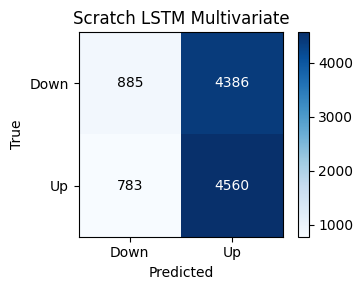

  ✓ Saved LSTM Multivariate Scratch → /Users/mihiniboteju/cryptoflow/results/classification_results.csv
Model saved → /Users/mihiniboteju/cryptoflow/models/lstm_multivariate_scratch.pkl


In [6]:
# ── Evaluate Scratch LSTM on test set ─────────────────────────────────────────
print("Predicting on test set (scratch) …")
y_prob_scratch = scratch_model.predict_proba(X_test)

metrics_scratch = compute_metrics(y_test, y_prob_scratch)
print("\n── Scratch LSTM Multivariate ──")
for k, v in metrics_scratch.items():
    print(f"  {k:10s}: {v:.4f}")

plot_confusion_matrix(y_test, y_prob_scratch, "Scratch LSTM Multivariate")
save_results('LSTM Multivariate Scratch', metrics_scratch)

# Save model
scratch_path = os.path.join(MODELS_DIR, 'lstm_multivariate_scratch.pkl')
with open(scratch_path, 'wb') as f:
    pickle.dump(scratch_model, f)
print(f"Model saved → {scratch_path}")

## Part 2 — PyTorch LSTM Classifier

Full BPTT via autograd, with:
- `nn.LSTM(input_size=20, hidden_size=64, num_layers=1, batch_first=True)`
- `Dropout(0.3)` on the last hidden state
- `Linear(64 → 1)` + `Sigmoid`
- `BCELoss`
- Adam optimiser, ReduceLROnPlateau scheduler
- Early stopping on validation AUC

In [7]:
class LSTMClassifierPyTorch(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers=1, dropout=0.3):
        super().__init__()
        self.lstm    = nn.LSTM(input_dim, hidden_dim, n_layers,
                               batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq, features)
        _, (h_n, _) = self.lstm(x)   # h_n: (n_layers, batch, hidden)
        h_last = self.dropout(h_n[-1])
        return torch.sigmoid(self.fc(h_last)).squeeze(1)


# ── DataLoaders ────────────────────────────────────────────────────────────────
def make_loader(X, y, batch_size, shuffle=False):
    Xt = torch.tensor(X)
    yt = torch.tensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr,  y_tr,  BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val, y_val, BATCH_SIZE)
test_loader  = make_loader(X_test, y_test, BATCH_SIZE)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pt_model  = LSTMClassifierPyTorch(N_FEATURES, HIDDEN, N_LAYERS).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(pt_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                        factor=0.5, patience=5)

print(f"Device: {device}")
print(pt_model)
print(f"\nTrainable params: {sum(p.numel() for p in pt_model.parameters() if p.requires_grad):,}")

Device: cpu
LSTMClassifierPyTorch(
  (lstm): LSTM(20, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable params: 22,081


Training PyTorch LSTM …

  Epoch   1  loss=0.6926  val_auc=0.5113  ← best
  Epoch   2  loss=0.6912  val_auc=0.5150  ← best
  Epoch   3  loss=0.6911  val_auc=0.5179  ← best
  Epoch   5  loss=0.6902  val_auc=0.5224  ← best
  Epoch   7  loss=0.6896  val_auc=0.5234  ← best
  Epoch   8  loss=0.6892  val_auc=0.5239  ← best
  Epoch  10  loss=0.6881  val_auc=0.5223
  Epoch  13  loss=0.6858  val_auc=0.5246  ← best
  Epoch  15  loss=0.6837  val_auc=0.5234
  Epoch  20  loss=0.6722  val_auc=0.5221

Early stop at epoch 23

Best val AUC (PyTorch): 0.5246


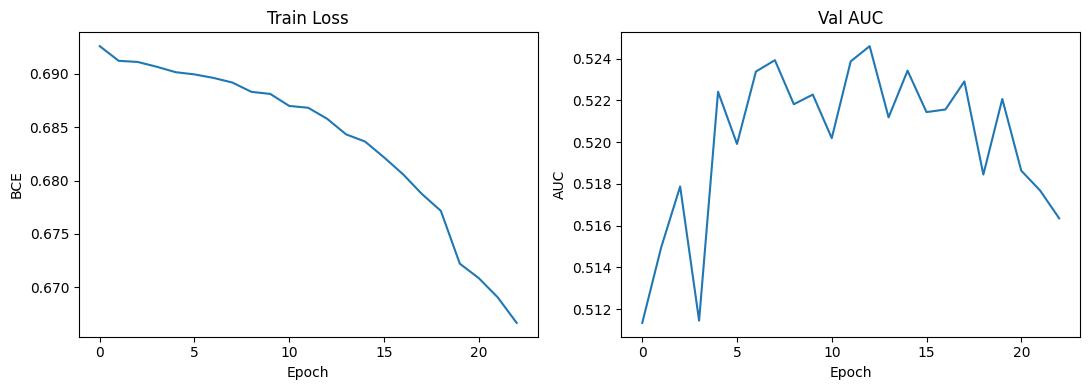

In [8]:
# ── Training loop ──────────────────────────────────────────────────────────────
best_val_auc_pt = 0.0
best_state      = None
patience_ctr    = 0
train_losses, val_aucs = [], []

print("Training PyTorch LSTM …\n")
for epoch in range(1, EPOCHS + 1):

    # — Train —
    pt_model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = pt_model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(pt_model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(Xb)
    epoch_loss = running_loss / len(X_tr)

    # — Validate —
    pt_model.eval()
    val_probs = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_probs.append(pt_model(Xb.to(device)).cpu().numpy())
    val_probs = np.concatenate(val_probs)
    val_auc   = roc_auc_score(y_val, val_probs)
    scheduler.step(val_auc)

    train_losses.append(epoch_loss)
    val_aucs.append(val_auc)

    marker = ""
    if val_auc > best_val_auc_pt:
        best_val_auc_pt = val_auc
        best_state      = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
        patience_ctr    = 0
        marker = "  ← best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or patience_ctr == 0:
        print(f"  Epoch {epoch:3d}  loss={epoch_loss:.4f}  val_auc={val_auc:.4f}{marker}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}")
        break

pt_model.load_state_dict(best_state)
print(f"\nBest val AUC (PyTorch): {best_val_auc_pt:.4f}")

# ── Training curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses); axes[0].set(title='Train Loss', xlabel='Epoch', ylabel='BCE')
axes[1].plot(val_aucs);     axes[1].set(title='Val AUC',   xlabel='Epoch', ylabel='AUC')
plt.tight_layout()
plt.show()

── PyTorch LSTM Multivariate ──
  auc       : 0.5295
  accuracy  : 0.5204
  precision : 0.5221
  recall    : 0.5564
  f1        : 0.5387


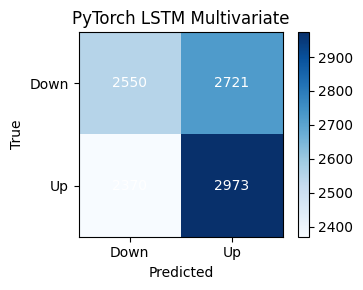

  ✓ Saved LSTM Multivariate PyTorch → /Users/mihiniboteju/cryptoflow/results/classification_results.csv
Model saved → /Users/mihiniboteju/cryptoflow/models/lstm_multivariate_pytorch.pth


In [9]:
# ── Evaluate PyTorch LSTM on test set ─────────────────────────────────────────
pt_model.eval()
y_prob_pt = []
with torch.no_grad():
    for Xb, _ in test_loader:
        y_prob_pt.append(pt_model(Xb.to(device)).cpu().numpy())
y_prob_pt = np.concatenate(y_prob_pt)

metrics_pt = compute_metrics(y_test, y_prob_pt)
print("── PyTorch LSTM Multivariate ──")
for k, v in metrics_pt.items():
    print(f"  {k:10s}: {v:.4f}")

plot_confusion_matrix(y_test, y_prob_pt, "PyTorch LSTM Multivariate")
save_results('LSTM Multivariate PyTorch', metrics_pt)

# Save model
pt_path = os.path.join(MODELS_DIR, 'lstm_multivariate_pytorch.pth')
torch.save(pt_model.state_dict(), pt_path)
print(f"Model saved → {pt_path}")

## ROC Curves — Both Models

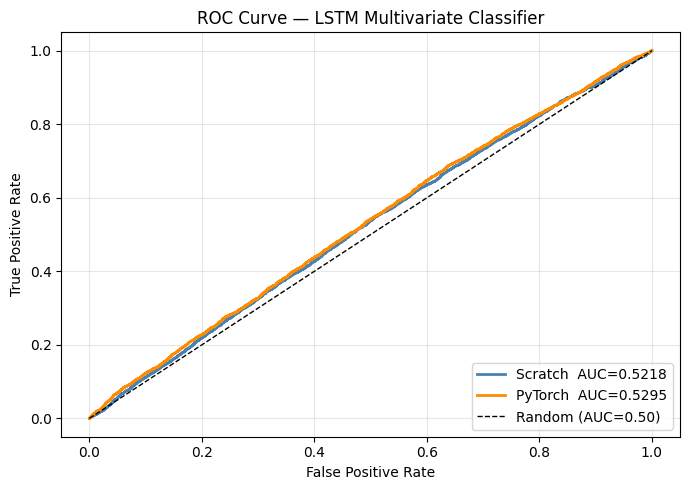

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

for probs, label, color in [
    (y_prob_scratch, f"Scratch  AUC={metrics_scratch['auc']:.4f}", 'steelblue'),
    (y_prob_pt,      f"PyTorch  AUC={metrics_pt['auc']:.4f}",      'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=label, lw=2, color=color)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve — LSTM Multivariate Classifier')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results Summary

In [11]:
# ── Load full results and display summary ──────────────────────────────────────
csv_path = os.path.join(RESULTS_DIR, 'classification_results.csv')
results  = pd.read_csv(csv_path)

# Sort by AUC descending and display
results_sorted = results.sort_values('auc', ascending=False).reset_index(drop=True)
results_sorted['rank'] = results_sorted.index + 1

# Highlight the multivariate LSTM rows
def highlight_new(row):
    if 'Multivariate' in str(row['model']):
        return ['background-color: #d4edda'] * len(row)
    elif row['model'] in ('LSTM Multivariate Scratch', 'LSTM Multivariate PyTorch'):
        return ['background-color: #d4edda'] * len(row)
    else:
        return [''] * len(row)

print("── All Models (sorted by AUC) ──\n")
display(results_sorted.style.apply(highlight_new, axis=1)
        .format({'auc': '{:.4f}', 'accuracy': '{:.4f}', 'precision': '{:.4f}',
                 'recall': '{:.4f}', 'f1': '{:.4f}'}))

# Side-by-side comparison: new models vs benchmark
print("\n── Comparison: New models vs XGBoost benchmark ──")
benchmark = results[results['model'] == 'XGBoost']
new_rows  = results[results['model'].str.contains('Multivariate', na=False)]
comparison = pd.concat([benchmark, new_rows], ignore_index=True)
display(comparison[['model', 'auc', 'accuracy', 'precision', 'recall', 'f1']]
        .style.format({'auc': '{:.4f}', 'accuracy': '{:.4f}',
                       'precision': '{:.4f}', 'recall': '{:.4f}', 'f1': '{:.4f}'}))

── All Models (sorted by AUC) ──



,model,accuracy,precision,sensitivity,specificity,tnr,f1,roc_auc,tp,tn,fp,fn,recall,auc,rank
0,LSTM Multivariate PyTorch,0.5204,0.5221,nan,nan,nan,0.5387,nan,nan,nan,nan,nan,0.5564,0.5295,1
1,LSTM Multivariate Scratch,0.5130,0.5097,nan,nan,nan,0.6383,nan,nan,nan,nan,nan,0.8535,0.5218,2
2,Majority Class Baseline,0.5034,0.5034,1.000000,0.000000,0.000000,0.6697,0.500000,5354.000000,0.000000,5281.000000,0.000000,nan,nan,3
3,Logistic Regression (Scratch),0.5236,0.5265,0.533400,0.513700,0.513700,0.5300,0.538800,2856.000000,2713.000000,2568.000000,2498.000000,nan,nan,4
4,Logistic Regression (sklearn),0.5247,0.5275,0.534700,0.514500,0.514500,0.5311,0.538600,2863.000000,2717.000000,2564.000000,2491.000000,nan,nan,5
5,Decision Tree (Scratch),0.5296,0.5327,0.533400,0.525700,0.525700,0.5331,0.529500,2856.000000,2776.000000,2505.000000,2498.000000,nan,nan,6
6,Decision Tree sklearn (depth=3),0.5308,0.5305,0.592100,0.468700,0.468700,0.5596,0.535900,3170.000000,2475.000000,2806.000000,2184.000000,nan,nan,7
7,Random Forest (Scratch),0.5230,0.5221,0.619500,0.425100,0.425100,0.5667,0.537800,3317.000000,2245.000000,3036.000000,2037.000000,nan,nan,8
8,"Random Forest sklearn (n=200, depth=10)",0.5308,0.5315,0.573200,0.487800,0.487800,0.5516,0.540500,3069.000000,2576.000000,2705.000000,2285.000000,nan,nan,9
9,KMeans Scratch,0.5034,0.5034,1.000000,0.000000,0.000000,0.6697,nan,5354.000000,0.000000,5281.000000,0.000000,nan,nan,10



── Comparison: New models vs XGBoost benchmark ──


,model,auc,accuracy,precision,recall,f1
0,XGBoost,nan,0.5331,0.5314,0.6152,0.5702
1,LSTM Multivariate Scratch,0.5218,0.5130,0.5097,0.8535,0.6383
2,LSTM Multivariate PyTorch,0.5295,0.5204,0.5221,0.5564,0.5387
